# Day 08. Exercise 04
# Regression

## 0. Imports

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [47]:
df = pd.read_csv('data/checker_regression.csv')

print(f"Размер: {df.shape}")
df.info()

Размер: (77, 4)
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          77 non-null     str    
 1   num_commits  77 non-null     int64  
 2   pageviews    59 non-null     float64
 3   AVG(diff)    18 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 2.5 KB


In [48]:
print(f"\nИнформация о пропущенных значениях:")
print(df.isnull().sum())

df.head()


Информация о пропущенных значениях:
uid             0
num_commits     0
pageviews      18
AVG(diff)      59
dtype: int64


,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN


In [49]:
df = df.drop_duplicates()
df = df.fillna(0)

print(f"Количество пропущенных значений для стоблцов после заполнения нулями:")
print(df.isnull().sum())

df.info()

Количество пропущенных значений для стоблцов после заполнения нулями:
uid            0
num_commits    0
pageviews      0
AVG(diff)      0
dtype: int64
<class 'pandas.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     str    
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.1 KB


In [50]:
X = df.drop('AVG(diff)', axis=1)
y = df['AVG(diff)']

X = pd.get_dummies(X)

print(f"X (размер): {X.shape}")
print(f"y (размер): {y.shape}")

X (размер): (29, 31)
y (размер): (29,)


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

print(f"Обучающая выборка (размер): {X_train.shape}")
print(f"Тестовая выборка (размер): {X_test.shape}")

Обучающая выборка (размер): (23, 31)
Тестовая выборка (размер): (6, 31)


## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [52]:
def crossval(n_splits, X, y, model_class):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_scores = []

    X = X.values if hasattr(X, 'values') else X
    y = y.values if hasattr(y, 'values') else y

    for train_idx, test_idx in kf.split(X):
        X_train_fold, X_test_fold = X[train_idx], X[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]

        model_class.fit(X_train_fold, y_train_fold)

        train_rmse = np.sqrt(mean_squared_error(y_train_fold, model_class.predict(X_train_fold)))
        test_rmse = np.sqrt(mean_squared_error(y_test_fold, model_class.predict(X_test_fold)))

        rmse_scores.append(test_rmse)
        print(f"train - {train_rmse:>20.13f}   |   test - {test_rmse:>20.13f}")

    average_rmse = np.mean(rmse_scores)
    print(f"Average RMSE on crossval is {average_rmse}\n")
    return average_rmse


In [53]:
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(max_depth=10, random_state=21)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=21)

In [54]:
print("="*60)
print("Линейная регрессия - Cross-Validation (10 folds)")
print("="*60)
lr_cv_rmse = crossval(10, X_train, y_train, lr_model)

Линейная регрессия - Cross-Validation (10 folds)
train -      0.0000000000002   |   test -    115.2393787651938
train -      0.0000000000001   |   test -     69.3579412125912
train -      0.0000000000000   |   test -     52.3954188621349
train -      0.0000000000001   |   test -     78.1858529722173
train -      0.0000000000001   |   test -     58.6694929109506
train -      0.0000000000001   |   test -     32.1007679447655
train -      0.0000000000001   |   test -     48.5931730548505
train -      0.0000000000000   |   test -     82.4173973533151
train -      0.0000000000001   |   test -     43.8116453580131
train -      0.0000000000001   |   test -     70.4721482840677
Average RMSE on crossval is 65.12432167180995



In [55]:
print("="*60)
print("Дерево решений - Cross-Validation (10 folds)")
print("="*60)
dt_cv_rmse = crossval(10, X_train, y_train, dt_model)

print("="*60)
print("Случайный лес - Cross-Validation (10 folds)")
print("="*60)
rf_cv_rmse = crossval(10, X_train, y_train, rf_model)

Дерево решений - Cross-Validation (10 folds)
train -      0.0000000000000   |   test -    151.1499476237642
train -      0.7905694150421   |   test -     64.8599716768819
train -      4.2676376933242   |   test -      9.0932667397366
train -      5.4703611572250   |   test -     57.1430667546379
train -      0.0000000000000   |   test -     80.2566196646731
train -      2.5178375985833   |   test -     15.2027957955108
train -      0.0000000000000   |   test -     55.6257334533417
train -      0.5143444998736   |   test -    122.5220819099788
train -      0.0000000000000   |   test -     50.4874241767195
train -      0.0000000000000   |   test -     80.2566196646731
Average RMSE on crossval is 68.65975274599178

Случайный лес - Cross-Validation (10 folds)
train -     19.5703116517653   |   test -    118.2975078622006
train -     20.9812464420610   |   test -     68.7390388391999
train -     27.4328500710776   |   test -     19.9090892559152
train -     24.3602303011568   |   test -    

## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [56]:
lr_final = LinearRegression().fit(X_train, y_train)
dt_final = DecisionTreeRegressor(max_depth=10, random_state=21).fit(X_train, y_train)
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=21).fit(X_train, y_train)

y_pred_lr = lr_final.predict(X_test)
y_pred_dt = dt_final.predict(X_test)
y_pred_rf = rf_final.predict(X_test)

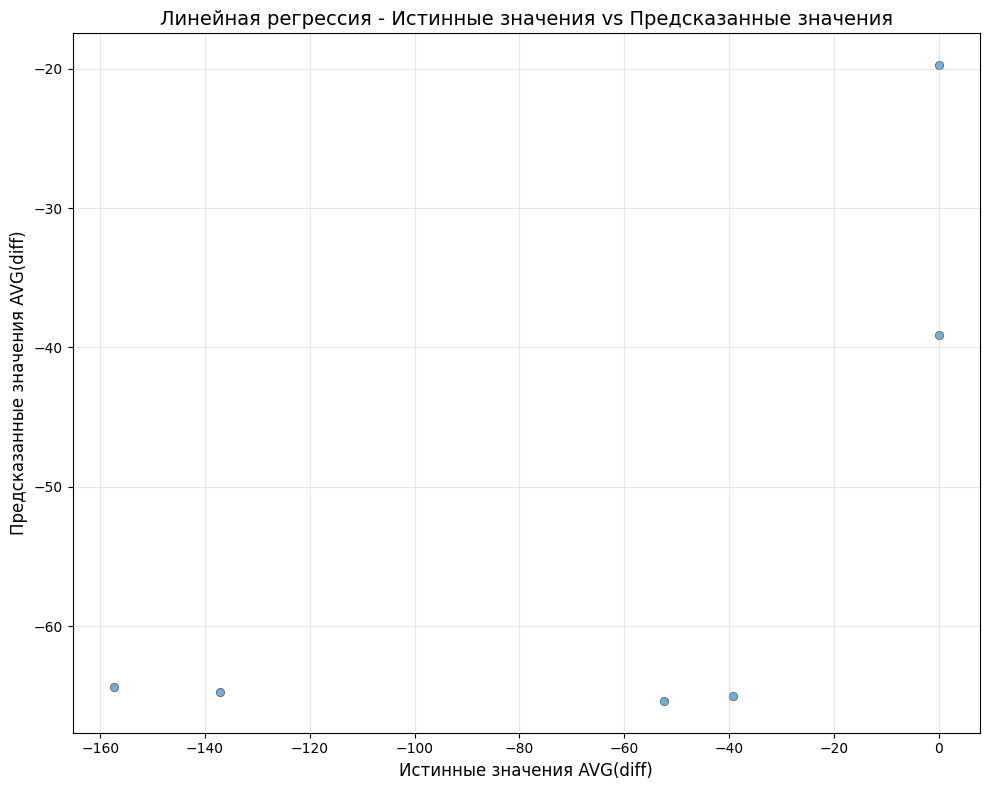

In [57]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_lr, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('Истинные значения AVG(diff)', fontsize=12)
plt.ylabel('Предсказанные значения AVG(diff)', fontsize=12)
plt.title('Линейная регрессия - Истинные значения vs Предсказанные значения', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

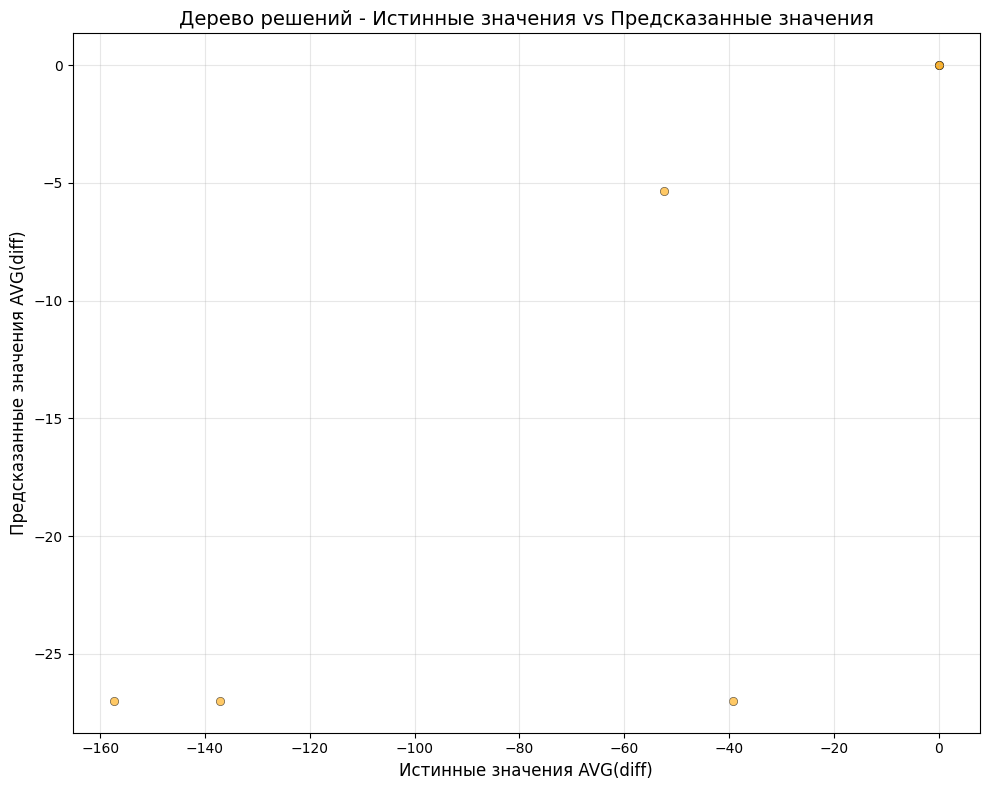

In [58]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_dt, alpha=0.6, edgecolors='black', linewidth=0.5, color='orange')
plt.xlabel('Истинные значения AVG(diff)', fontsize=12)
plt.ylabel('Предсказанные значения AVG(diff)', fontsize=12)
plt.title('Дерево решений - Истинные значения vs Предсказанные значения', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

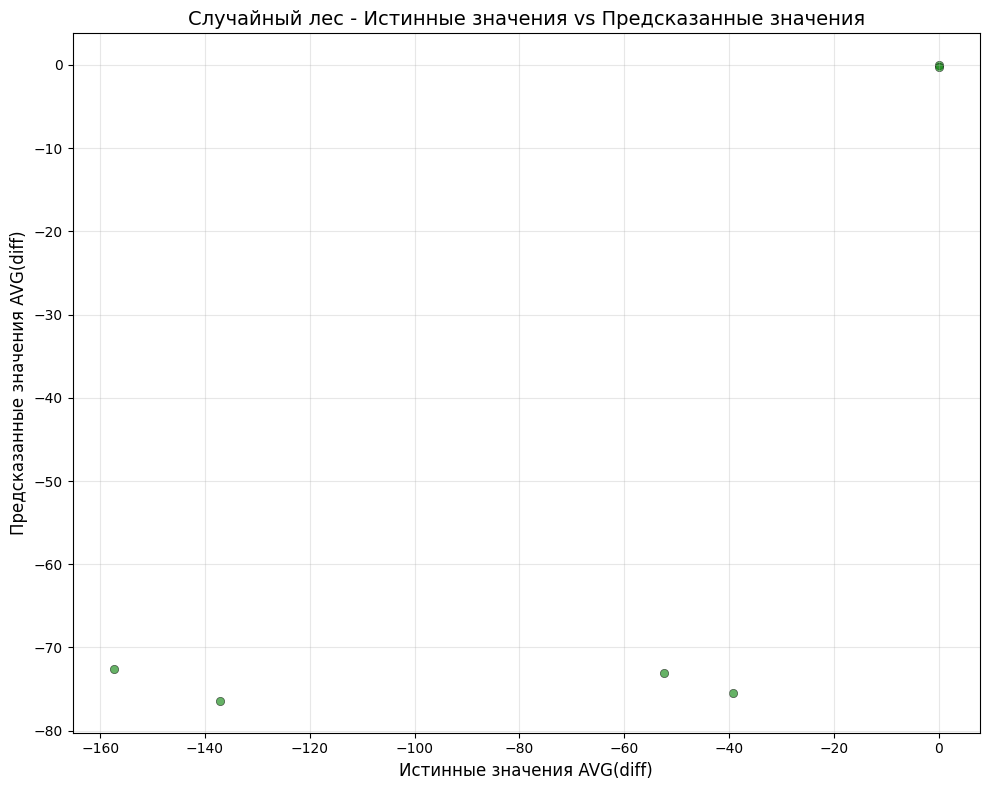

In [59]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='black', linewidth=0.5, color='green')
plt.xlabel('Истинные значения AVG(diff)', fontsize=12)
plt.ylabel('Предсказанные значения AVG(diff)', fontsize=12)
plt.title('Случайный лес - Истинные значения vs Предсказанные значения', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Вопрос: Как бы на графике был изображен идеальный случай?**

**Ответ: В идеальном случае (ideal case) все точки лежали бы вдоль диагонали y = x - это означало бы, что предсказанные значения всегда точно совпадают с действительными значениями (равны им).**